# Deliverable 5: Proposed Improvement — Scene Prior Global Module (SPGM)

**Syed Ibrahim Bin Hassan** (27100201) , **Asad Riaz** (27100055)

**Proposed Modification:** Scene Prior Global Module (SPGM)

---

## Pipeline Overview
1. **Dataset Preparation** — Same as Deliverable 3: DOTA v1.5 filtered to 4 classes, 640×640 patches, YOLO HBB format
2. **Model Modification** — SPGM block inserted on the **P3 detect input path only**
3. **Training** — Same hyperparameters as baseline (20 epochs, batch 8, img 640) for fair comparison
4. **Evaluation** — mAP@0.5, mAP@0.5:0.95, per-class AP



## 1. Setup and Imports


In [1]:
!pip install -q ultralytics

import os
import random
import warnings
import types
from pathlib import Path

import cv2
import yaml
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

from ultralytics import YOLO
from ultralytics.models.yolo.detect import DetectionTrainer
from ultralytics.nn.tasks import DetectionModel
from ultralytics.utils import RANK

warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["WANDB_MODE"] = "disabled"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Torch:", torch.__version__)

Torch: 2.10.0+cu128


## 2. Path Configuration

In [2]:
DATASET_ROOT = Path("/kaggle/input/datasets/ishwarghoshrony/dota-dataset")

TRAIN_IMG_DIRS = [
    DATASET_ROOT / "train" / "part1" / "images",
    DATASET_ROOT / "train" / "part2" / "images",
    DATASET_ROOT / "train" / "part3" / "images",
]
TRAIN_ANN_DIR = DATASET_ROOT / "train" / "DOTA-v1.5_train"

VAL_IMG_DIRS = [DATASET_ROOT / "valid" / "part1" / "images"]
VAL_ANN_DIR = Path("/kaggle/input/datasets/ishwarghoshrony/dota-dataset/valid/labelTxt-v1.5_valid-20250901T101921Z-1-001/labelTxt-v1.5/DOTA-v1.5_val")

WORK_DIR = Path("/kaggle/working")
YOLO_DATASET_DIR = WORK_DIR / "dota_yolo"

SELECTED_CLASSES = ['plane', 'ship', 'small-vehicle', 'large-vehicle']
CLASS_TO_ID = {cls: i for i, cls in enumerate(SELECTED_CLASSES)}
PATCH_SIZE = 640
PATCH_OVERLAP = 128

print("Classes:", SELECTED_CLASSES)

Classes: ['plane', 'ship', 'small-vehicle', 'large-vehicle']


## 3. DOTA Annotation Parser

In [3]:
def parse_dota_annotation(ann_path):
    objects = []
    with open(ann_path, 'r') as f:
        lines = f.readlines()
    for line in lines:
        line = line.strip()
        if line.startswith('imagesource') or line.startswith('gsd') or len(line) == 0:
            continue
        parts = line.split()
        if len(parts) < 10:
            continue
        try:
            coords = [float(parts[i]) for i in range(8)]
            objects.append({'poly': coords, 'category': parts[8], 'difficulty': int(parts[9])})
        except (ValueError, IndexError):
            continue
    return objects

def obb_to_hbb(poly):
    xs = [poly[0], poly[2], poly[4], poly[6]]
    ys = [poly[1], poly[3], poly[5], poly[7]]
    return [min(xs), min(ys), max(xs), max(ys)]

def hbb_to_yolo(hbb, img_w, img_h):
    xmin, ymin, xmax, ymax = hbb
    return [
        max(0, min(1, (xmin + xmax) / 2 / img_w)),
        max(0, min(1, (ymin + ymax) / 2 / img_h)),
        max(0, min(1, (xmax - xmin) / img_w)),
        max(0, min(1, (ymax - ymin) / img_h)),
    ]

def find_image_path(stem, img_dirs):
    for d in img_dirs:
        for ext in ['.png', '.jpg', '.bmp', '.tif']:
            p = d / f"{stem}{ext}"
            if p.exists():
                return p
    return None

def get_objects_in_patch(objects, x_start, y_start, ps, min_area=20):
    result = []
    for obj in objects:
        xmin, ymin, xmax, ymax = obb_to_hbb(obj['poly'])
        cx = max(xmin, x_start) - x_start
        cy = max(ymin, y_start) - y_start
        cx2 = min(xmax, x_start + ps) - x_start
        cy2 = min(ymax, y_start + ps) - y_start
        cw, ch = cx2 - cx, cy2 - cy
        if cw < 2 or ch < 2:
            continue
        original_area = (xmax - xmin) * (ymax - ymin)
        clipped_area = cw * ch
        if original_area > 0 and (clipped_area / original_area) < 0.5:
            continue
        if clipped_area < min_area:
            continue
        result.append({'hbb': [cx, cy, cx2, cy2], 'category': obj['category'], 'difficulty': obj['difficulty']})
    return result

def create_patches(img_dirs, ann_dir, out_img, out_lbl, sel_cls, cls2id, ps, ov):
    Path(out_img).mkdir(parents=True, exist_ok=True)
    Path(out_lbl).mkdir(parents=True, exist_ok=True)
    stride = ps - ov
    stats = {'imgs': 0, 'patches': 0, 'objects': 0, 'skip': 0}

    for af in tqdm(sorted(Path(ann_dir).glob('*.txt')), desc='Patching'):
        ip = find_image_path(af.stem, img_dirs)
        if ip is None:
            continue

        objs = [o for o in parse_dota_annotation(af) if o['category'] in sel_cls]
        if not objs:
            stats['skip'] += 1
            continue

        img = cv2.imread(str(ip))
        if img is None:
            continue

        h, w = img.shape[:2]
        stats['imgs'] += 1

        for ys in range(0, h, stride):
            for xs in range(0, w, stride):
                xe, ye = min(xs + ps, w), min(ys + ps, h)
                xa, ya = max(0, xe - ps), max(0, ye - ps)

                patch_objs = get_objects_in_patch(objs, xa, ya, ps)
                if not patch_objs:
                    continue

                patch = img[ya:ya + ps, xa:xa + ps]
                ph, pw = patch.shape[:2]
                if ph < ps or pw < ps:
                    pad = np.zeros((ps, ps, 3), dtype=np.uint8)
                    pad[:ph, :pw] = patch
                    patch = pad

                name = f"{af.stem}_{xa}_{ya}"
                cv2.imwrite(str(Path(out_img) / f"{name}.jpg"), patch)

                lines = []
                for o in patch_objs:
                    if o['category'] not in cls2id:
                        continue
                    yb = hbb_to_yolo(o['hbb'], ps, ps)
                    if yb[2] < 0.002 or yb[3] < 0.002:
                        continue
                    lines.append(f"{cls2id[o['category']]} {yb[0]:.6f} {yb[1]:.6f} {yb[2]:.6f} {yb[3]:.6f}")

                if lines:
                    with open(Path(out_lbl) / f"{name}.txt", 'w') as f:
                        f.write('\n'.join(lines))
                    stats['patches'] += 1
                    stats['objects'] += len(lines)

    return stats

## 4. Image Patching and Subset Creation


In [4]:
train_img_out = YOLO_DATASET_DIR / 'images' / 'train'
train_lbl_out = YOLO_DATASET_DIR / 'labels' / 'train'
val_img_out = YOLO_DATASET_DIR / 'images' / 'val'
val_lbl_out = YOLO_DATASET_DIR / 'labels' / 'val'

n_train = len(list(train_img_out.glob('*.jpg'))) if train_img_out.exists() else 0
n_val = len(list(val_img_out.glob('*.jpg'))) if val_img_out.exists() else 0

if n_train > 100 and n_val > 100:
    print(f"Dataset exists: {n_train} train, {n_val} val. Skipping.")
else:
    print(f"Found {n_train} train, {n_val} val -> recreating both splits...")
    import shutil
    if YOLO_DATASET_DIR.exists():
        shutil.rmtree(YOLO_DATASET_DIR)

    ts = create_patches(TRAIN_IMG_DIRS, TRAIN_ANN_DIR, train_img_out, train_lbl_out, SELECTED_CLASSES, CLASS_TO_ID, PATCH_SIZE, PATCH_OVERLAP)
    vs = create_patches(VAL_IMG_DIRS, VAL_ANN_DIR, val_img_out, val_lbl_out, SELECTED_CLASSES, CLASS_TO_ID, PATCH_SIZE, PATCH_OVERLAP)
    print(f"Train patches: {ts['patches']}, objects: {ts['objects']}")
    print(f"Val patches:   {vs['patches']}, objects: {vs['objects']}")

Found 0 train, 0 val -> recreating both splits...


Patching: 100%|██████████| 458/458 [01:21<00:00,  5.61it/s]

Train patches: 16523, objects: 377325
Val patches:   5010, objects: 121530


## 5. Create Dataset YAML Config


In [5]:
dataset_yaml = {
    'path': str(YOLO_DATASET_DIR),
    'train': 'images/train',
    'val': 'images/val',
    'nc': len(SELECTED_CLASSES),
    'names': SELECTED_CLASSES
}

yaml_path = YOLO_DATASET_DIR / 'dataset.yaml'
yaml_path.parent.mkdir(parents=True, exist_ok=True)
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print("Using dataset YAML:", yaml_path)

Using dataset YAML: /kaggle/working/dota_yolo/dataset.yaml


## 6.1 SPGM-P3 Module Definition

SPGM (Scene Prior Global Module) injects scene-level context into the high-resolution detection branch.
In this notebook, the module is configured as **P5 -> P3** only:
1. A global scene prior is extracted from `P5` (coarser, semantic features).
2. That prior is projected to a spatial gate for `P3`.
3. `P3` is reweighted with a residual gated form:
   `P3' = P3 + alpha * (P3 * gate3)`

Why this design: `P3` carries small-object detail; adding global context from `P5` helps suppress clutter and emphasize scene-consistent responses while keeping compute lightweight.


In [6]:
class SPGM_P3(nn.Module):
    """
    Scene Prior Gating Module for P3 only, using P5 as scene source.

    P3' = P3 + alpha * (P3 * gate3)
    gate3 is channel-wise from GAP(P5) -> MLP -> sigmoid.
    """
    def __init__(self, c3, c5, reduction=4, alpha=0.2):
        super().__init__()
        assert alpha != 0.0, "alpha must be non-zero for SPGM residual gating."
        hidden = max(c5 // reduction, 16)

        self.scene_mlp = nn.Sequential(
            nn.Conv2d(c5, hidden, kernel_size=1, bias=True),
            nn.SiLU(inplace=True),
            nn.Conv2d(hidden, c3, kernel_size=1, bias=True),
            nn.Sigmoid(),
        )
        self.alpha = float(alpha)

    def forward(self, p3, p5):
        scene = p5.mean(dim=(2, 3), keepdim=True)
        gate3 = self.scene_mlp(scene)
        return p3 + self.alpha * (p3 * gate3)

## 6.2 Detect Head Patching Helpers

In [7]:
def get_detect_module(model):
    return model.model[-1]

def infer_detect_in_channels(detect):
    ch = []
    if hasattr(detect, 'cv2'):
        for branch in detect.cv2:
            m = branch[0]
            if hasattr(m, 'conv') and hasattr(m.conv, 'in_channels'):
                ch.append(int(m.conv.in_channels))
            elif hasattr(m, 'in_channels'):
                ch.append(int(m.in_channels))
            else:
                raise RuntimeError('Could not infer channels from detect.cv2 branch.')
        return ch
    if hasattr(detect, 'm'):
        for m in detect.m:
            if hasattr(m, 'in_channels'):
                ch.append(int(m.in_channels))
            elif hasattr(m, 'conv') and hasattr(m.conv, 'in_channels'):
                ch.append(int(m.conv.in_channels))
            else:
                raise RuntimeError('Could not infer channels from detect.m branch.')
        return ch
    raise RuntimeError('Unsupported Detect head layout.')

def attach_spgm_p3_to_detect(model, reduction=4, alpha=0.2):
    assert alpha != 0.0, 'SPGM alpha must be non-zero.'
    detect = get_detect_module(model)

    base_forward = getattr(detect, '_original_forward_spgm', detect.forward)
    base_forward_fn = base_forward.__func__ if hasattr(base_forward, '__func__') else base_forward
    detect._original_forward_spgm_fn = base_forward_fn

    in_channels = infer_detect_in_channels(detect)
    assert len(in_channels) >= 3, f'Expected >=3 detect scales, got {len(in_channels)}'
    c3, c5 = in_channels[0], in_channels[2]

    detect.spgm_p3 = SPGM_P3(c3=c3, c5=c5, reduction=reduction, alpha=alpha)

    def forward_with_spgm(self, x):
        assert isinstance(x, (list, tuple)) and len(x) >= 3, 'Detect expected P3,P4,P5 feature list.'
        x = list(x)
        p3, p5 = x[0], x[2]

        p = next(self.spgm_p3.parameters(), None)
        if p is not None and (p.device != p3.device or p.dtype != p3.dtype):
            self.spgm_p3.to(device=p3.device, dtype=p3.dtype)

        x[0] = self.spgm_p3(p3, p5)
        return self._original_forward_spgm_fn(self, x)

    detect.__class__.forward_with_spgm = forward_with_spgm
    detect.forward_with_spgm = types.MethodType(detect.__class__.forward_with_spgm, detect)
    detect.forward = detect.forward_with_spgm
    return model

class SPGMTrainer(DetectionTrainer):
    def get_model(self, cfg=None, weights=None, verbose=True):
        model = DetectionModel(
            cfg,
            nc=self.data['nc'],
            ch=self.data['channels'],
            verbose=verbose and RANK == -1,
        )
        attach_spgm_p3_to_detect(model, reduction=4, alpha=0.2)
        if weights is not None:
            model.load(weights)
        return model

## 7. Verification + Training

In [8]:
base_model = YOLO('yolov5s.pt')

trainer_args = {
    'model': 'yolov5s.pt',
    'data': str(yaml_path),
    'imgsz': 640,
    'epochs': 1,
    'batch': 8,
    'workers': 2,
    'project': '/kaggle/working/runs',
    'name': 'yolov5s_spgm_smoketest',
    'seed': SEED,
    'cache': False,
    'device': 0 if torch.cuda.is_available() else 'cpu',
    'verbose': True,
    'amp': False,
}

trainer = SPGMTrainer(overrides=trainer_args, _callbacks=base_model.callbacks)
trainer.data = trainer.get_dataset()
trainer.model = trainer.get_model(weights=base_model.model, cfg=base_model.model.yaml)

spgm_params = [n for n, _ in trainer.model.named_parameters() if 'spgm' in n.lower()]
print('Number of SPGM parameter tensors:', len(spgm_params))
print('Sample SPGM params:', spgm_params[:8])
assert len(spgm_params) > 0, 'SPGM params not found in trainer model.'

detect = trainer.model.model[-1]
assert hasattr(detect, 'spgm_p3'), 'Detect head missing spgm_p3.'
assert detect.spgm_p3.alpha != 0.0, 'SPGM alpha must be non-zero.'

trainer.model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, 640, 640, device=next(trainer.model.parameters()).device)
    _ = trainer.model(dummy)

print('Trainer-side SPGM verification passed.')

PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dota_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=

In [9]:
EPOCHS = 20
BATCH_SIZE = 8
IMG_SIZE = 640

model = YOLO('yolov5s.pt')
results = model.train(
    data=str(yaml_path),
    imgsz=IMG_SIZE,
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    workers=2,
    project='/kaggle/working/runs',
    name='yolov5s_spgm',
    seed=SEED,
    cache=False,
    amp=False,
    device=0 if torch.cuda.is_available() else 'cpu',
    trainer=SPGMTrainer,
)
print('Training finished.')

PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dota_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj

## 8. SPGM Evaluation and Analysis

In [ ]:
# RUNS_ROOT = Path('/kaggle/working/runs')
# spgm_runs = sorted(RUNS_ROOT.glob('yolov5s_spgm*'), key=lambda p: p.stat().st_mtime, reverse=True)
# assert spgm_runs, 'No yolov5s_spgm* run directories found.'

# SPGM_RUN_DIR = spgm_runs[0]
# SPGM_BEST = SPGM_RUN_DIR / 'weights' / 'best.pt'
# assert SPGM_BEST.exists(), f'SPGM best.pt not found: {SPGM_BEST}'

# print('Using run dir:', SPGM_RUN_DIR)
# print('Using weights:', SPGM_BEST)

# spgm_eval = YOLO(str(SPGM_BEST))
# metrics = spgm_eval.val(
#     data=str(yaml_path),
#     imgsz=IMG_SIZE,
#     batch=BATCH_SIZE,
#     split='val',
#     project='/kaggle/working/runs',
#     name='yolov5s_spgm_eval',
#     exist_ok=True,
#     verbose=True,
# )
# print(metrics.results_dict)

Using run dir: /kaggle/working/runs/yolov5s_spgm-3
Using weights: /kaggle/working/runs/yolov5s_spgm-3/weights/best.pt
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv5s summary (fused): 89 layers, 9,195,260 parameters, 0 gradients, 23.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2528.5±397.9 MB/s, size: 143.2 KB)
val: Scanning /kaggle/working/dota_yolo/labels/val.cache... 4542 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4542/4542 1.9Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 568/568 8.9it/s 1:04<0.1ss
                   all       4542     108874      0.875      0.816       0.87      0.603
                 plane       1012       4425      0.916      0.925      0.961      0.733
                  ship       1358      20641      0.934      0.901      0.951      0.681
         small-vehicle       2738      72995      0.822      0.649      0.714      0.366

In [16]:
import subprocess
result = subprocess.run(['find', '/kaggle/working/runs', '-name', 'results.csv'], 
                      capture_output=True, text=True)
print(result.stdout)

# Also list all run directories
import os
for root, dirs, files in os.walk('/kaggle/working/runs'):
    level = root.replace('/kaggle/working/runs', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        subindent = ' ' * 2 * (level + 1)
        for file in files:
            print(f'{subindent}{file}')

/kaggle/working/runs/yolov5s_spgm-3/results.csv

runs/
  yolov5s_spgm_smoketest/
    args.yaml
    weights/
  yolov5s_spgm/
    args.yaml
    weights/
  yolov5s_spgm-2/
    args.yaml
    weights/
  yolov5s_spgm_eval/
    val_batch2_labels.jpg
    val_batch0_labels.jpg
    BoxF1_curve.png
    BoxR_curve.png
    val_batch1_labels.jpg
    BoxP_curve.png
    val_batch1_pred.jpg
    val_batch2_pred.jpg
    BoxPR_curve.png
    confusion_matrix_normalized.png
    confusion_matrix.png
    val_batch0_pred.jpg
  yolov5s_spgm-3/
    train_batch0.jpg
    results.png
    val_batch2_labels.jpg
    results.csv
    val_batch0_labels.jpg
    BoxF1_curve.png
    BoxR_curve.png
    labels.jpg
    train_batch18760.jpg
    train_batch1.jpg
    train_batch2.jpg
    val_batch1_labels.jpg
    BoxP_curve.png
    val_batch1_pred.jpg
    train_batch18762.jpg
    val_batch2_pred.jpg
    BoxPR_curve.png
    train_batch18761.jpg
    confusion_matrix_normalized.png
    confusion_matrix.png
    args.yaml
    val_batc

## 8. YOLOv5 + SPGM Metrics Summary


In [17]:
SPGM_RUN_DIR = Path('/kaggle/working/runs/yolov5s_spgm-3')
results_csv = SPGM_RUN_DIR / 'results.csv'

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

map50_col = pick_col(df, ['metrics/mAP_0.5', 'metrics/mAP50(B)'])
map95_col = pick_col(df, ['metrics/mAP_0.5:0.95', 'metrics/mAP50-95(B)'])
p_col = pick_col(df, ['metrics/precision', 'metrics/precision(B)'])
r_col = pick_col(df, ['metrics/recall', 'metrics/recall(B)'])
epoch_col = pick_col(df, ['epoch'])

best_idx = df[map50_col].idxmax()
print('YOLOv5s + SPGM Summary')
print('=' * 50)
print(f"Best Epoch:   {int(df.loc[best_idx, epoch_col])}")
print(f"mAP@0.5:      {df.loc[best_idx, map50_col]:.4f}")
if map95_col: print(f"mAP@0.5:0.95: {df.loc[best_idx, map95_col]:.4f}")
if p_col:     print(f"Precision:    {df.loc[best_idx, p_col]:.4f}")
if r_col:     print(f"Recall:       {df.loc[best_idx, r_col]:.4f}")

YOLOv5s + SPGM Summary
Best Epoch:   20
mAP@0.5:      0.8697
mAP@0.5:0.95: 0.6030
Precision:    0.8745
Recall:       0.8163


In [19]:
DATA_YAML = yaml_path
SPGM_RUN_DIR = Path('/kaggle/working/runs/yolov5s_spgm-3')
BEST_WEIGHTS = SPGM_RUN_DIR / 'weights' / 'best.pt'
LAST_WEIGHTS = SPGM_RUN_DIR / 'weights' / 'last.pt'

print('best exists:', BEST_WEIGHTS.exists(), BEST_WEIGHTS)
print('last exists:', LAST_WEIGHTS.exists(), LAST_WEIGHTS)

ckpt_path = BEST_WEIGHTS if BEST_WEIGHTS.exists() else LAST_WEIGHTS
assert ckpt_path.exists(), f'No checkpoint found in {SPGM_RUN_DIR}'

ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
state_dict = None

if isinstance(ckpt, dict):
    if 'model' in ckpt and hasattr(ckpt['model'], 'state_dict'):
        state_dict = ckpt['model'].state_dict()
    elif 'state_dict' in ckpt:
        state_dict = ckpt['state_dict']
else:
    raise RuntimeError('Unexpected checkpoint format.')

spgm_keys = [k for k in state_dict.keys() if 'spgm' in k.lower()]
print('SPGM keys in checkpoint:', len(spgm_keys))
print('Sample checkpoint keys:', spgm_keys[:20])
assert len(spgm_keys) > 0, 'Checkpoint does not contain SPGM weights.'
print('Checkpoint verification passed.')

best exists: True /kaggle/working/runs/yolov5s_spgm-3/weights/best.pt
last exists: True /kaggle/working/runs/yolov5s_spgm-3/weights/last.pt
SPGM keys in checkpoint: 4
Sample checkpoint keys: ['model.24.spgm_p3.scene_mlp.0.weight', 'model.24.spgm_p3.scene_mlp.0.bias', 'model.24.spgm_p3.scene_mlp.2.weight', 'model.24.spgm_p3.scene_mlp.2.bias']
Checkpoint verification passed.


In [20]:
with open(DATA_YAML, 'r') as f:
    dataset_info = yaml.safe_load(f)

trained_spgm_model = load_trained_spgm_checkpoint(
    ckpt_path,
    base_weights='yolov5s.pt',
    nc=int(dataset_info['nc']),
    ch=3,
)
print('Reloaded trained SPGM model.')

PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1      3520  ultralytics.nn.modules.conv.Conv             [3, 32, 6, 2, 2]              
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     18816  ultralytics.nn.modules.block.C3              [64, 64, 1]                   
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    115712  ultralytics.nn.modules.block.C3              [128, 128, 2]                 
  5                 

## 9. SPGM Evaluation and Analysis

In [21]:
print('=' * 60)
print('SPGM: YOLOv5s + SPGM Evaluation')
print('=' * 60)

spgm_eval = YOLO(str(SPGM_BEST))
spgm_eval_metrics = spgm_eval.val(
    data=str(DATA_YAML),
    imgsz=640,
    batch=8,
    split='val',
    project='/kaggle/working/runs',
    name='yolov5s_spgm_eval',
    exist_ok=True,
    verbose=True,
)
print(spgm_eval_metrics.results_dict)

SPGM: YOLOv5s + SPGM Evaluation
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv5s summary (fused): 89 layers, 9,195,260 parameters, 0 gradients, 23.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2576.6±1116.3 MB/s, size: 143.4 KB)
val: Scanning /kaggle/working/dota_yolo/labels/val.cache... 4542 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4542/4542 1.7Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 568/568 8.8it/s 1:04<0.1ss
                   all       4542     108874      0.875      0.816       0.87      0.603
                 plane       1012       4425      0.916      0.925      0.961      0.733
                  ship       1358      20641      0.934      0.901      0.951      0.681
         small-vehicle       2738      72995      0.822      0.649      0.714      0.366
         large-vehicle       1193      10813      0.827      0.789      0.852      0

## 10. Training Curves

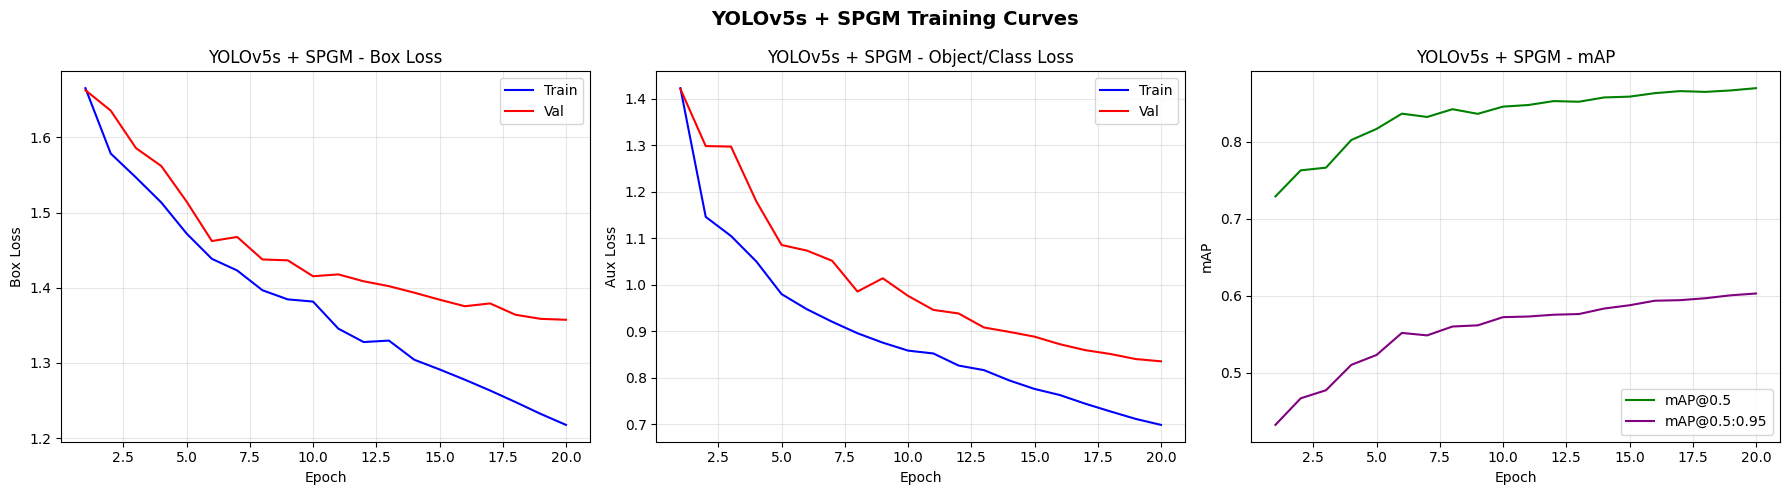

YOLOv5s + SPGM Best Results (Epoch 20):
  mAP@0.5:      0.8697
  mAP@0.5:0.95: 0.6030
  Precision:    0.8745
  Recall:       0.8163


In [ ]:
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def plot_training_curves(results_csv_path, model_name):
    df = pd.read_csv(results_csv_path)
    df.columns = df.columns.str.strip()

    epoch_col = pick_col(df, ['epoch'])
    box_train_col = pick_col(df, ['train/box_loss'])
    box_val_col = pick_col(df, ['val/box_loss'])
    aux_train_col = pick_col(df, ['train/obj_loss', 'train/cls_loss'])
    aux_val_col = pick_col(df, ['val/obj_loss', 'val/cls_loss'])
    map50_col = pick_col(df, ['metrics/mAP_0.5', 'metrics/mAP50(B)'])
    map5095_col = pick_col(df, ['metrics/mAP_0.5:0.95', 'metrics/mAP50-95(B)'])
    prec_col = pick_col(df, ['metrics/precision', 'metrics/precision(B)'])
    rec_col = pick_col(df, ['metrics/recall', 'metrics/recall(B)'])

    if epoch_col is None or map50_col is None:
        print(f'Could not parse expected metric columns in {results_csv_path}')
        print('Available columns:', list(df.columns))
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    if box_train_col and box_val_col:
        axes[0].plot(df[epoch_col], df[box_train_col], label='Train', color='blue')
        axes[0].plot(df[epoch_col], df[box_val_col], label='Val', color='red')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Box Loss')
    axes[0].set_title(f'{model_name} - Box Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if aux_train_col and aux_val_col:
        axes[1].plot(df[epoch_col], df[aux_train_col], label='Train', color='blue')
        axes[1].plot(df[epoch_col], df[aux_val_col], label='Val', color='red')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Aux Loss')
    axes[1].set_title(f'{model_name} - Object/Class Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(df[epoch_col], df[map50_col], label='mAP@0.5', color='green')
    if map5095_col:
        axes[2].plot(df[epoch_col], df[map5095_col], label='mAP@0.5:0.95', color='purple')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('mAP')
    axes[2].set_title(f'{model_name} - mAP')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'{model_name} Training Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    best_epoch = df[map50_col].idxmax()
    print(f'{model_name} Best Results (Epoch {int(df.loc[best_epoch, epoch_col])}):')
    print(f"  mAP@0.5:      {df.loc[best_epoch, map50_col]:.4f}")
    if map5095_col:
        print(f"  mAP@0.5:0.95: {df.loc[best_epoch, map5095_col]:.4f}")
    if prec_col:
        print(f"  Precision:    {df.loc[best_epoch, prec_col]:.4f}")
    if rec_col:
        print(f"  Recall:       {df.loc[best_epoch, rec_col]:.4f}")

if results_csv.exists():
    plot_training_curves(results_csv, 'YOLOv5s + SPGM')
else:
    print(f'SPGM results.csv not found: {results_csv}')

In [ ]:
# def get_best_metrics(results_csv_path):
#     df = pd.read_csv(results_csv_path)
#     df.columns = df.columns.str.strip()

#     map50_col = pick_col(df, ['metrics/mAP_0.5', 'metrics/mAP50(B)'])
#     map5095_col = pick_col(df, ['metrics/mAP_0.5:0.95', 'metrics/mAP50-95(B)'])
#     prec_col = pick_col(df, ['metrics/precision', 'metrics/precision(B)'])
#     rec_col = pick_col(df, ['metrics/recall', 'metrics/recall(B)'])
#     epoch_col = pick_col(df, ['epoch'])

#     best_idx = df[map50_col].idxmax()
#     out = {'mAP@0.5': df.loc[best_idx, map50_col], 'Best Epoch': int(df.loc[best_idx, epoch_col])}
#     if map5095_col:
#         out['mAP@0.5:0.95'] = df.loc[best_idx, map5095_col]
#     if prec_col:
#         out['Precision'] = df.loc[best_idx, prec_col]
#     if rec_col:
#         out['Recall'] = df.loc[best_idx, rec_col]
#     return out

# if results_csv.exists():
#     metrics = get_best_metrics(results_csv)
#     print('YOLOv5s + SPGM Summary')
#     print('=' * 50)
#     print(f"Best Epoch:   {metrics['Best Epoch']}")
#     print(f"mAP@0.5:      {metrics['mAP@0.5']:.4f}")
#     if 'mAP@0.5:0.95' in metrics:
#         print(f"mAP@0.5:0.95: {metrics['mAP@0.5:0.95']:.4f}")
#     if 'Precision' in metrics:
#         print(f"Precision:    {metrics['Precision']:.4f}")
#     if 'Recall' in metrics:
#         print(f"Recall:       {metrics['Recall']:.4f}")
# else:
#     print('SPGM results.csv not found.')

YOLOv5s + SPGM Summary
Best Epoch:   20
mAP@0.5:      0.8697
mAP@0.5:0.95: 0.6030
Precision:    0.8745
Recall:       0.8163


## 11. Inference Visualization


In [25]:
import shutil

val_images = sorted((YOLO_DATASET_DIR / 'images' / 'val').glob('*.jpg'))
sample_val = random.sample(val_images, min(8, len(val_images)))

sample_dir = WORK_DIR / 'sample_inference_spgm'
sample_dir.mkdir(exist_ok=True)
for img in sample_val:
    shutil.copy(img, sample_dir / img.name)

spgm_infer = YOLO(str(SPGM_BEST))
spgm_infer.predict(
    source=str(sample_dir),
    imgsz=640,
    conf=0.25,
    project='/kaggle/working/runs',
    name='yolov5s_spgm_inference',
    exist_ok=True,
    save=True,
    save_txt=True,
    save_conf=True,
)


image 1/8 /kaggle/working/sample_inference_spgm/P0019_4608_512.jpg: 640x640 3 ships, 14.7ms
image 2/8 /kaggle/working/sample_inference_spgm/P1023_3072_440.jpg: 640x640 3 ships, 14.8ms
image 3/8 /kaggle/working/sample_inference_spgm/P1314_3360_2560.jpg: 640x640 7 ships, 14.7ms
image 4/8 /kaggle/working/sample_inference_spgm/P1398_3414_2048.jpg: 640x640 4 planes, 14.7ms
image 5/8 /kaggle/working/sample_inference_spgm/P2231_1024_512.jpg: 640x640 2 planes, 49 small-vehicles, 1 large-vehicle, 14.7ms
image 6/8 /kaggle/working/sample_inference_spgm/P2242_1024_526.jpg: 640x640 11 planes, 94 small-vehicles, 5 large-vehicles, 14.7ms
image 7/8 /kaggle/working/sample_inference_spgm/P2331_2634_512.jpg: 640x640 100 small-vehicles, 1 large-vehicle, 13.6ms
image 8/8 /kaggle/working/sample_inference_spgm/P2802_2048_3584.jpg: 640x640 1 plane, 2 small-vehicles, 2 large-vehicles, 13.6ms
Speed: 1.6ms preprocess, 14.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kagg

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'plane', 1: 'ship', 2: 'small-vehicle', 3: 'large-vehicle'}
 obb: None
 orig_img: array([[[45, 69, 57],
         [49, 73, 61],
         [51, 75, 63],
         ...,
         [54, 80, 62],
         [47, 74, 54],
         [40, 67, 47]],
 
        [[40, 64, 52],
         [45, 69, 57],
         [48, 72, 60],
         ...,
         [55, 81, 63],
         [50, 77, 57],
         [44, 71, 51]],
 
        [[37, 61, 51],
         [43, 67, 57],
         [48, 72, 62],
         ...,
         [53, 79, 61],
         [50, 77, 57],
         [46, 73, 53]],
 
        ...,
 
        [[21, 22, 18],
         [24, 25, 21],
         [27, 28, 24],
         ...,
         [22, 27, 18],
         [22, 26, 20],
         [29, 33, 27]],
 
        [[16, 17, 15],
         [23, 24, 22],
         [27, 28, 24],
         ...,
         [35, 39, 33],
         [32, 36, 31],
   

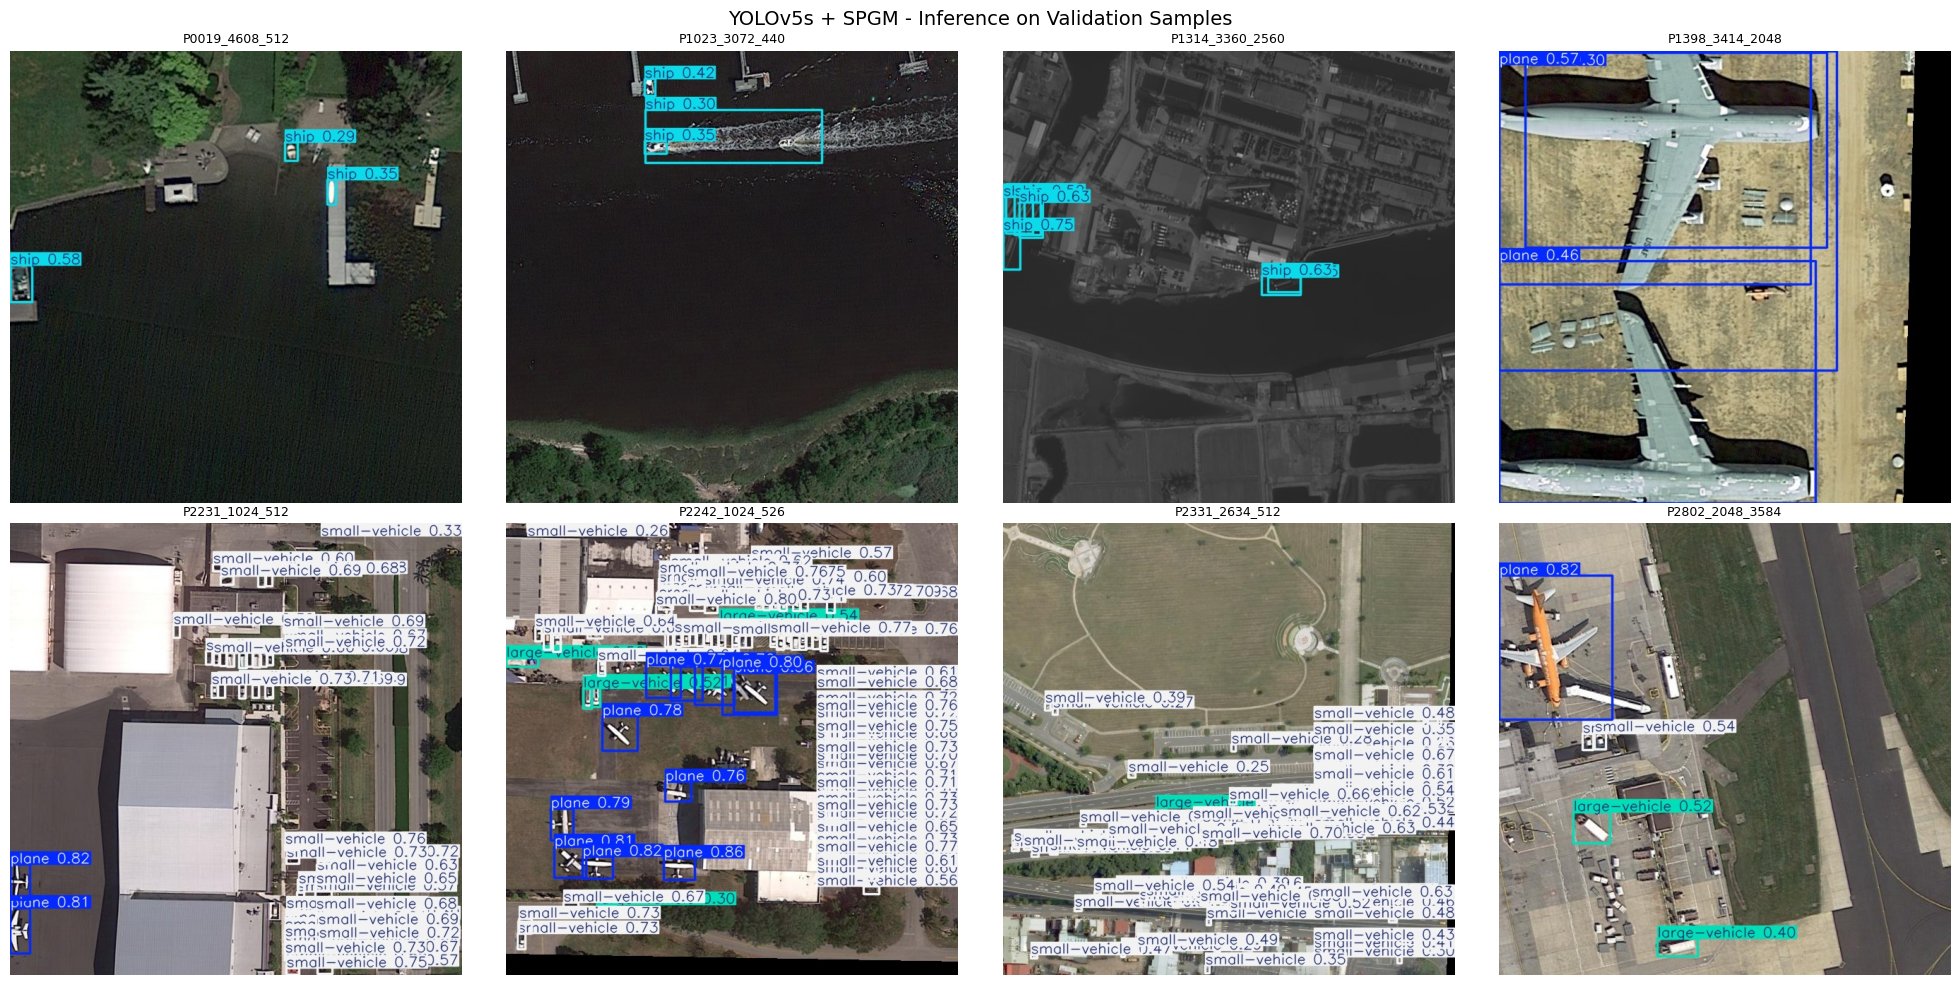

In [26]:
inference_dir = Path('/kaggle/working/runs/yolov5s_spgm_inference')
inference_images = sorted(inference_dir.glob('*.jpg'))

if len(inference_images) > 0:
    n_show = min(8, len(inference_images))
    cols = 4
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = axes.flatten() if n_show > 1 else [axes]
    for idx, img_path in enumerate(inference_images[:n_show]):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img)
        axes[idx].set_title(img_path.stem, fontsize=9)
        axes[idx].axis('off')
    for idx in range(n_show, len(axes)):
        axes[idx].axis('off')
    plt.suptitle('YOLOv5s + SPGM - Inference on Validation Samples', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No inference images found.')

## 13. YOLOv5 + SPGM: Generated Evaluation Plots


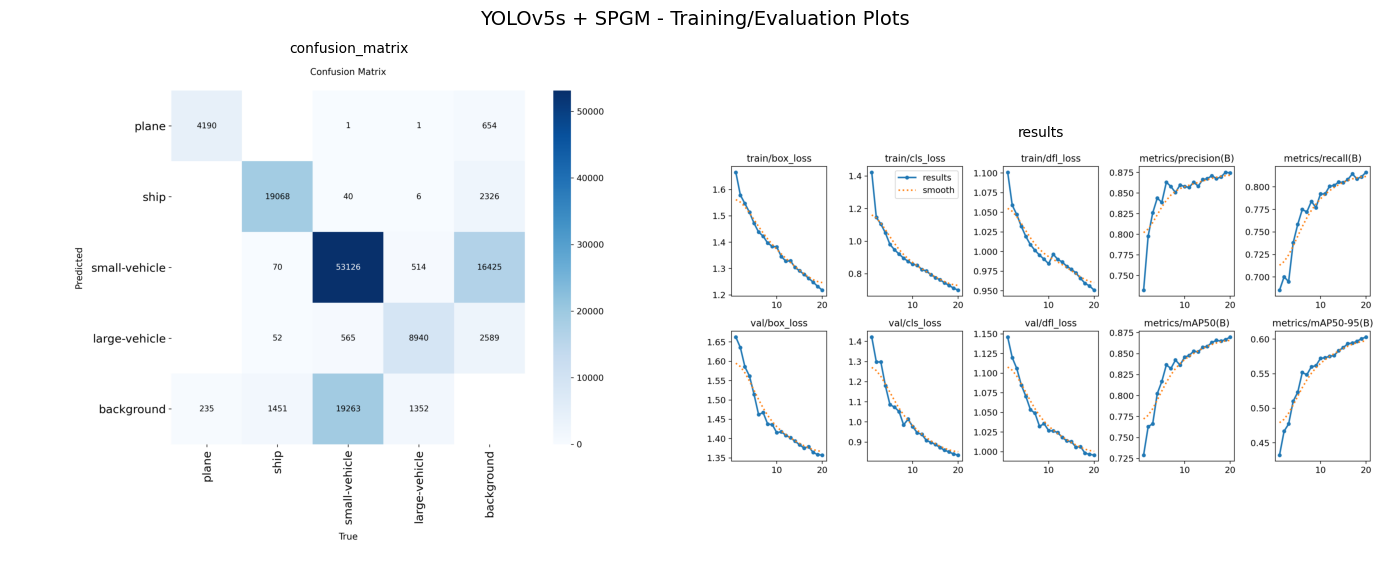

In [29]:
plot_names = ['confusion_matrix.png', 'P_curve.png', 'R_curve.png', 'PR_curve.png', 'results.png']
available_plots = [SPGM_RUN_DIR / p for p in plot_names if (SPGM_RUN_DIR / p).exists()]
if available_plots:
    cols = min(3, len(available_plots))
    rows = (len(available_plots) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows))
    axes = axes.flatten() if len(available_plots) > 1 else [axes]
    for idx, plot_path in enumerate(available_plots):
        img = cv2.imread(str(plot_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img)
        axes[idx].set_title(plot_path.stem, fontsize=10)
        axes[idx].axis('off')
    for idx in range(len(available_plots), len(axes)):
        axes[idx].axis('off')
    plt.suptitle('YOLOv5s + SPGM - Training/Evaluation Plots', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f'No plots found at {SPGM_RUN_DIR}')

## 14. Model Complexity Comparison


In [28]:
def get_model_info(weights_path):
    ckpt = torch.load(weights_path, map_location='cpu', weights_only=False)
    model = ckpt.get('model', ckpt.get('ema', None))
    n_params = sum(p.numel() for p in model.parameters()) if model is not None and hasattr(model, 'parameters') else 0
    file_size_mb = os.path.getsize(weights_path) / (1024 * 1024)
    return n_params, file_size_mb

print('Model Complexity Summary')
print('=' * 55)
print(f"{'Model':<20} {'Parameters':>15} {'Weight File':>15}")
print('-' * 55)
if SPGM_BEST.exists():
    n_params, size_mb = get_model_info(SPGM_BEST)
    print(f"{'YOLOv5s + SPGM':<20} {n_params:>12,} p {size_mb:>12.1f} MB")
else:
    print(f"{'YOLOv5s + SPGM':<20} {'weights not found':>30}")

Model Complexity Summary
Model                     Parameters     Weight File
-------------------------------------------------------
YOLOv5s + SPGM          9,205,916 p         17.8 MB
